# CNN forward pass from scratch

here i take one digit and push it through the whole CNN pipeline by hand: convolution, relu, max pooling, flatten, then a dense layer with softmax. the weights are random so the prediction wont be right, the point is just to see every step happen.

shape (8, 8)  true label 7


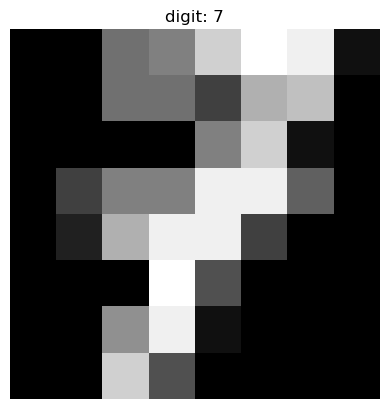

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits

digits = load_digits()
image = digits.images[7]      # one 8x8 digit
label = digits.target[7]

print('shape', image.shape, ' true label', label)
plt.imshow(image, cmap='gray')
plt.title(f'digit: {label}')
plt.axis('off')
plt.show()

## step 1, convolution

slide a couple of edge filters over the digit. each filter gives back its own feature map.

In [2]:
def convolve(image, kernel):
    h, w = image.shape
    k = kernel.shape[0]
    out = np.zeros((h - k + 1, w - k + 1))
    for i in range(h - k + 1):
        for j in range(w - k + 1):
            out[i, j] = np.sum(image[i:i+k, j:j+k] * kernel)
    return out

each feature map is (6, 6)


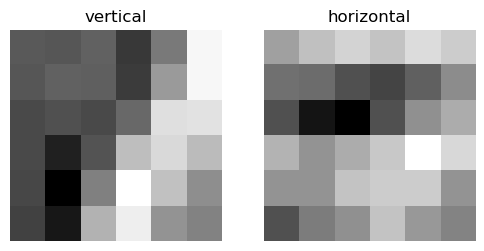

In [8]:
vert = np.array([[1, 0, -1],
                 [1, 0, -1],
                 [1, 0, -1]])

horiz = np.array([[ 1,  1,  1],
                  [ 0,  0,  0],
                  [-1, -1, -1]])

fmaps = [convolve(image, vert), convolve(image, horiz)]
print('each feature map is', fmaps[0].shape)   # 8x8 -> 6x6

fig, ax = plt.subplots(1, 2, figsize=(6, 3))
ax[0].imshow(fmaps[0], cmap='gray'); ax[0].set_title('vertical')
ax[1].imshow(fmaps[1], cmap='gray'); ax[1].set_title('horizontal')
for a in ax: a.axis('off')
plt.show()

## step 2, relu

just clip the negatives to zero. keeps the strong activations, drops the rest.

In [3]:
def relu(x):
    return np.maximum(0, x)

fmaps = [relu(f) for f in fmaps]
print(fmaps[0])

[[ 0.  0.  0.  0.  0. 39.]
 [ 0.  0.  0.  0.  8. 39.]
 [ 0.  0.  0.  0. 31. 32.]
 [ 0.  0.  0. 20. 29. 19.]
 [ 0.  0.  0. 42. 21.  4.]
 [ 0.  0. 16. 36.  6.  0.]]


## step 3, max pooling

take the max in each 2x2 block. it shrinks the map by half and gives a little bit of shift tolerance, becuase the max barely moves if the digit moves a pixel.

In [4]:
def max_pool(x, size=2):
    h, w = x.shape
    out = np.zeros((h // size, w // size))
    for i in range(0, h - size + 1, size):
        for j in range(0, w - size + 1, size):
            out[i // size, j // size] = np.max(x[i:i+size, j:j+size])
    return out

pooled = [max_pool(f) for f in fmaps]
print('after pooling', pooled[0].shape)   # 6x6 -> 3x3

after pooling (3, 3)


## step 4, flatten then dense then softmax

stack the pooled maps into one vector, run it through a dense layer to 10 outputs (one per digit), and softmax turns those into probabilities.

In [5]:
flat = np.concatenate([p.flatten() for p in pooled])
print('flattened length', flat.shape)

rng = np.random.default_rng(0)
W = rng.normal(0, 1, (flat.shape[0], 10))   # random dense weights
b = np.zeros(10)

scores = flat @ W + b

flattened length (18,)


In [6]:
def softmax(z):
    e = np.exp(z - np.max(z))
    return e / np.sum(e)

probs = softmax(scores)
print('probs    ', np.round(probs, 3))
print('predicted', np.argmax(probs), ' actual', label)

probs     [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
predicted 9  actual 7


the prediction is basically a guess right now becuase the dense weights are random. training is what makes those weights mean something, and thats the next notebook where i let pytorch learn them.

### what i learned

a CNN is just convolve, relu, pool, flatten, dense, softmax stacked together. nothing magic, every step is a small numpy operation. the only missing piece is learning the filter and dense weights instead of hardcoding them.